In [ ]:
cd tumbling_git/

/share/nas2/pryder/tumbling_git


In [33]:
import numpy as np
import matplotlib.pyplot as plt
from skyfield.api import load, EarthSatellite, wgs84
from pc_utils import open_vdif, iq_conversion, range_finder_general, rect
import ephem
from scipy.constants import c
from datetime import datetime, timedelta
import os
import scipy.signal as signal

In [3]:
def calculate_bistatic_geometry(tx_tot, pytime, sat_tle, rx, pulsewidth, toa_bias, vdif_sample_rate):
    """
    Calculates bistatic range, TOA, and maps them to VDIF sample indices.
    
    Parameters:
    -----------
    tx_tot : numpy.ndarray
        Array of transmit times (seconds past midnight).
    pytime : datetime.date or datetime.datetime
        The base date of the observation.
    sat_tle : list or tuple
        The 3 TLE strings for ephem.readtle (Name, Line 1, Line 2).
    rx : str
        The RX site name ('Lovell', 'Knockin', 'Cambridge', or 'Mark2').
    pulsewidth : float
        Pulse width in seconds.
    toa_bias : float
        System hardware/calibration delay bias in seconds.
    vdif_sample_rate : float
        The sampling rate of your VDIF data in Hz (e.g., 64e6 for 64 MHz).
        
    Returns:
    --------
    dict
        Contains arrays for bistatic ranges, predicted TOAs, and target sample offsets.
    """
    num_pulses = len(tx_tot)
    
    # Initialize PyEphem Target and Observers
    sat = ephem.readtle(sat_tle[0], sat_tle[1], sat_tle[2])
    
    tx_site = ephem.Observer()
    tx_site.lat, tx_site.lon, tx_site.elevation = 50.04807632702485, -5.18104490171712, 128.8136
    
    rx_site = ephem.Observer()
    if rx == 'Lovell':
        rx_site.lat, rx_site.lon, rx_site.elevation = 53.236739628000954, -2.3085154887549506, 85.0392
    elif rx=='Knockin':
        rx_site.lat, rx_site.lon, rx_site.elevation = 52.790138, -2.996851, 71.0
    elif rx=='Mark2':
        rx_site.lat, rx_site.lon, rx_site.elevation = 53.234096, -2.303869, 82.0
    elif rx=='Cambridge':
        rx_site.lat, rx_site.lon, rx_site.elevation = 52.1669, 0.0372, 21.3360
    else:
        raise ValueError("Invalid RX site. Choose from 'Lovell', 'Knockin', 'Cambridge', or 'Mark2', or add another in line 227 of goonhilly_pc_utils.py.")
    
    # Pre-allocate output arrays
    bistatic_ranges_m = np.zeros(num_pulses)
    rx_toas_sec = np.zeros(num_pulses)
    vdif_sample_indices = np.zeros(num_pulses, dtype=np.int64)
    
    # Extract base date components
    yr, mo, dy = pytime.year, pytime.month, pytime.day
    
    for ii, tot in enumerate(tx_tot):
        # enumerate cycles through elements in tx_tot, tot, and their index, ii
        # 1. Initial rough estimate of Uplink Time of Flight (TOF)
        tx_site.date = ephem.date((yr, mo, dy, 0, 0, tot))
        # print(ii, tx_site.date)
        sat.compute(tx_site)
        tof_tx_to_sat = sat.range / c
        
        # 2. Light-time correction (satellite position at true intercept time)
        tx_site.date = ephem.date((yr, mo, dy, 0, 0, tot + tof_tx_to_sat))
        sat.compute(tx_site)
        tx_range = sat.range
        tof_tx_to_sat = tx_range / c  # Refined uplink delay
        
        # 3. Downlink calculation from the true intercept time
        rx_site.date = ephem.date((yr, mo, dy, 0, 0, tot + tof_tx_to_sat))
        sat.compute(rx_site)
        rx_range = sat.range
        tof_sat_to_rx = rx_range / c  # Downlink delay
        
        # 4. Total Bistatic Parameters
        bistatic_range = tx_range + rx_range
        bistatic_ranges_m[ii] = bistatic_range
        
        # Predict exactly when the pulse center hits the receiver (seconds past midnight)
        toa_from_midnight = tot + (pulsewidth / 2.0) + tof_tx_to_sat + tof_sat_to_rx + toa_bias
        rx_toas_sec[ii] = toa_from_midnight
        
        # 5. Map TOA directly to a VDIF sample index relative to midnight
        # Note: If your VDIF data stream resets its frame/sample counters at midnight, 
        # this gives you the absolute expected sample index of the echo peak.
        vdif_sample_indices[ii] = int(round(toa_from_midnight * vdif_sample_rate))
        
    return {
        "bistatic_range_km": bistatic_ranges_m / 1e3,
        "rx_toa_sec": rx_toas_sec,
        "vdif_target_sample_idx": vdif_sample_indices
    }

In [4]:
def calculate_observed_bistatic_range(pc_output_window, pipeline_geometry, vdif_sample_rate, search_window_size):
    """
    Calculates the actual observed bistatic range from the pulse compression output.
    
    Parameters:
    -----------
    pc_output_window : numpy.ndarray
        The 1D array output of your pulse compression for a single pulse.
    pipeline_geometry : dict
        The geometry dictionary containing the theoretical 'bistatic_range_km' 
        and 'rx_toa_sec' for this specific pulse.
    vdif_sample_rate : float
        The sampling rate of your VDIF data in Hz.
    search_window_size : int
        The total number of samples in the pc_output_window grid.
    """
    
    # 1. Find the index of the maximum peak in the real data
    observed_peak_idx = np.argmax(np.abs(pc_output_window))
    
    # 2. Calculate how far the real peak is from the center of your search window
    # (Assuming your search window was centered on the theoretical target index)
    center_idx = search_window_size // 2
    sample_residual = observed_peak_idx - center_idx
    
    # 3. Convert sample residual into a time residual (seconds)
    time_residual = sample_residual / vdif_sample_rate
    
    # 4. Calculate the true observed Round Trip Time (RTT)
    # Theoretical RTT = theoretical range / c
    theoretical_range_m = pipeline_geometry['bistatic_range_km'] * 1e3
    theoretical_rtt = theoretical_range_m / c
    
    observed_rtt = theoretical_rtt + time_residual
    
    # 5. Calculate final Observed Bistatic Range
    observed_bistatic_range_km = (observed_rtt * c) / 1e3
    
    return {
        "observed_range_km": observed_bistatic_range_km,
        "range_residual_km": (sample_residual * c / vdif_sample_rate) / 1e3,
        "time_residual_sec": time_residual,
        "peak_snr": np.abs(pc_output_window[observed_peak_idx]) / np.std(pc_output_window)
    }

In [5]:
tle_line_1 = '1 61995U 16053M   25035.62796428  .00000095  00000-0  00000-0 0  9998'
tle_line_2 = '2 61995   0.2642  88.1708 0053675 268.4745   3.2920  1.01033442  1106'
target_name = 'intelsat'
ts = load.timescale()
intelsat_tle = EarthSatellite(tle_line_1, tle_line_2, target_name, ts)
tle_list = [target_name, tle_line_1, tle_line_2]

In [6]:
lovell = wgs84.latlon(53.2365, -2.3087)
t = ts.utc(2025, 5, 2, 13, 45, 0)  # Example time; adjust as needed
difference = intelsat_tle - lovell

topocentric = difference.at(t)
el, az, distance = topocentric.altaz()
distance_km = distance.km
print(distance_km*2)

88303.88196055655


In [96]:
# input parameters       
bw = 8e6        
Tp = 800e-6    
pri = 19.7e-3
freq = 1295e6
c = 299792458
samp_rate = 16e6
alpha = bw/Tp   
height = 128 # CPI Size
points = int(samp_rate * pri)
infilename = '/share/nas2/pryder/SET_Observations_Test_1/Wednesday/vdifs/TSSat_20250205_lo1_1295MHz_intelsat33e.vdifa'

In [97]:
# Open VDIF
pola, header = open_vdif(infilename, 0)
print('VDIF opened.')

# Convert to IQ
iq_samples = iq_conversion(pola)
print('Converted into IQ samples.')

VDIF opened.
Converted into IQ samples.


In [93]:
ts = load.timescale()
freqs = np.fft.fftfreq(points, d=1/samp_rate) # Used for Fourier Shift RCM correction
startoffset = int(samp_rate * 10)
overlap_factor = 'min'
rejected = 0
accepted = 0

if overlap_factor == 'max':
    cpi_jump_samples = 1
    number_of_strips = 200
    overlap_factor = 1

elif overlap_factor == 'min':
    cpi_jump_samples = height * points
    number_of_strips = int((len(iq_samples) - startoffset - (height * points)) // cpi_jump_samples)

else:
    cpi_jump_samples = (height * points) // overlap_factor
    number_of_strips = int((len(iq_samples) - startoffset - (height * points)) // cpi_jump_samples)

rcm_map = np.zeros((points, number_of_strips))
spectrogram = np.zeros((height, number_of_strips))

peak_history = []

print(f'Total strips to process: {number_of_strips}')


for n in range(number_of_strips):
    # n=n+15
    print(f"Processing strip {n+1} of {number_of_strips}", end='\r')
    
    start_idx = startoffset + (n * cpi_jump_samples)
    end_idx = start_idx + (height * points)
    cpi_data = iq_samples[start_idx:end_idx].reshape((height, points))
    
    # Update TLE range rate for the start of this CPI
    s_offset = (start_idx / samp_rate)
    t_tle = ts.utc(2025, 2, 5, 13, 45, s_offset)
    range_rate = range_finder_general(intelsat_tle, t_tle, 'lovell')[1]
    tau_dot = range_rate / c
    
    # Create template: baseband * chirp * envelope
    t_pulse = np.linspace(0, pri, points, endpoint=False)
    template = np.exp(1j * np.pi * alpha * t_pulse**2 * (1 - tau_dot)**2) * rect(t_pulse / (Tp * (1 + tau_dot)))
    template_fft = np.fft.fft(template)

    cdat_pc = np.zeros((height, points), dtype=complex)
    
    # Pulse Compression
    for i in range(height):
        start_sec = i * pri
        pulse_fft = np.fft.fft(cpi_data[i])
        
        # Calculating RCM Correction
        delta_tau = 2 * (range_rate * start_sec) / c     # change in range rate since beginning of CPI, converted to time delay
        rcm_shift = np.exp(1j * 2 * np.pi * freqs * delta_tau)          #applying RCM correction in the frequency domain using linear phase shift corresponding to the change in range delay over the CPI duration
        
        # Pulse Compression and RCM shift
        compressed_pulse = np.fft.ifft(pulse_fft * np.conj(template_fft) * rcm_shift)
        
        # Doppler Phase Correction
        f_d = -2 * range_rate * freq / c
        bulk_phase = np.exp(-1j * 2 * np.pi * f_d * start_sec)
        
        # applying doppler correction
        cdat_pc[i] = compressed_pulse * bulk_phase

    # power = np.abs(cdat_pc)**2
    # incoho_sum = np.sum(power, axis=0)
    # plt.plot(incoho_sum)
    # plt.xlabel('Range (km)')
    # plt.ylabel('Incoherent Sum Power')
    # plt.savefig(f'./plots/incoherent_sum_strip_{n+1}.png')
    # plt.show()

    # plt.imshow(power[:, 127000:129000], aspect='auto',vmin=0, vmax=5000, cmap='plasma', extent=[127000, 129000, 0, height*pri])
    # plt.colorbar(label='Power')
    # plt.xlabel('Range (km)')
    # plt.ylabel('Time (s)')
    # plt.savefig(f'./plots/rti_{n+1}.png')
    # plt.show()
    cdat_pc_trim = cdat_pc[:, 127075:129075]
    power = np.abs(cdat_pc)**2
    incoho_sum = np.sum(power, axis=0)
    peak = np.argmax(incoho_sum)


    # using single value decomposition (svd) theorem to split cdat_pc matrix into three components
    # left singular values -> slow time profiles (orthogonal matrix)
    # singular values - > strength of each component (diagonal matrix)
    # right singular values -> fast time profiles (conjugate transpose of orthogonal matrix)

    lsv, S, rsv = np.linalg.svd(cdat_pc_trim, full_matrices=False)
    S_cleaned = S.copy()
    number_dop_com = 2
    S_cleaned[:number_dop_com] = 0.0
    cleaned_cdat_pc = np.dot(lsv * S_cleaned, rsv)

    win_fast = signal.get_window('hann', 2000, fftbins=False)
    win_slow = signal.get_window('boxcar', height, fftbins=False)
    win_fast /= np.mean(win_fast)
    win_slow /= np.mean(win_slow)
    windowed_cdat_pc = cleaned_cdat_pc * win_slow[:, np.newaxis]



    unshifted_range_doppler = np.fft.fft(windowed_cdat_pc, axis=0)
    range_doppler = np.fft.fftshift(unshifted_range_doppler, axes=0)

    # max_velocity = c / (4 * pri * (freq))

    # lowest_value = -max_velocity

    # number_of_points = range_doppler.shape[0]
    # velocity_axis = np.linspace(lowest_value, max_velocity, number_of_points)
    # range_axis = np.linspace(0, pri * c / 2, cdat_pc.shape[1])
    # range_axis = range_axis[127075:129075]
    # plt.figure()
    # plt.pcolormesh(range_axis, velocity_axis, np.abs(range_doppler ** 2), shading="auto", vmax=3e6)
    # plt.colorbar()
    # plt.xlabel("Range (m)")
    # plt.ylabel("Velocity (m/s)")
    # plt.title('Intelsat 33e Debris from observations on 5/2/25 with Lovell')
    # # plt.xlim([range_axis[127075], range_axis[129075]])
    # plt.savefig(f'./plots/range_doppler_{n+1}.png')
    # plt.show()
    peak_offset = 128075- peak
    # print(peak_offset)
    if np.abs(peak_offset)<10:
        # print('\n accepted')
        accepted +=1
        spectrogram[:, n] = np.abs(range_doppler[:, 1000-peak_offset])**2
    else:
        # print('\n rejected')
        rejected +=1
        spectrogram[:, n] = np.abs(range_doppler[:, 1000])**2

print('Number of accepted = ', accepted)
print('Number of rejected = ', rejected)
print("acceptance rate = ", accepted/number_of_strips*100)


Total strips to process: 101
Number of accepted =  0 101
Number of rejected =  101
acceptance rate =  0.0


In [95]:
len(pola)

4277760000

Total strips to process: 105


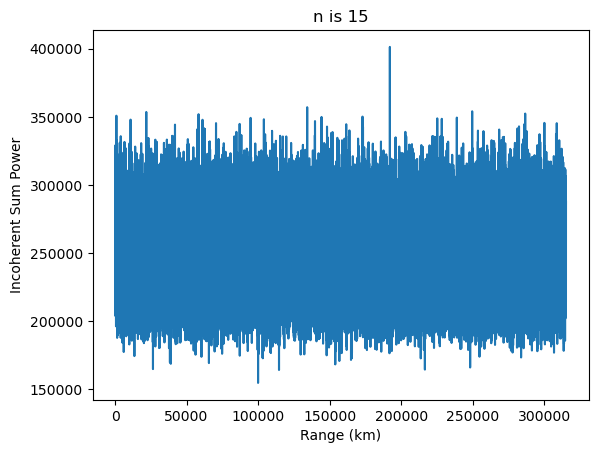

In [ ]:
ts = load.timescale()
freqs = np.fft.fftfreq(points, d=1/samp_rate) # Used for Fourier Shift RCM correction
startoffset = 0# int(samp_rate * 100)
overlap_factor = 'min'
rejected = 0
accepted = 0

if overlap_factor == 'max':
    cpi_jump_samples = 1
    number_of_strips = 200
    overlap_factor = 1

elif overlap_factor == 'min':
    cpi_jump_samples = height * points
    number_of_strips = int((len(iq_samples) - startoffset - (height * points)) // cpi_jump_samples)

else:
    cpi_jump_samples = (height * points) // overlap_factor
    number_of_strips = int((len(iq_samples) - startoffset - (height * points)) // cpi_jump_samples)

rcm_map = np.zeros((points, number_of_strips))
spectrogram = np.zeros((height, number_of_strips))

peak_history = []

print(f'Total strips to process: {number_of_strips}')


for n in range():
    n=15
    print(f"Processing strip {n+1} of {number_of_strips}", end='\r')
    
    start_idx = startoffset + (n * cpi_jump_samples)
    end_idx = start_idx + (height * points)
    cpi_data = iq_samples[start_idx:end_idx].reshape((height, points))
    
    # Update TLE range rate for the start of this CPI
    s_offset = (start_idx / samp_rate)
    t_tle = ts.utc(2025, 2, 5, 13, 45, s_offset)
    range_rate = range_finder_general(intelsat_tle, t_tle, 'lovell')[1]
    tau_dot = range_rate / c
    
    # Create template: baseband * chirp * envelope
    t_pulse = np.linspace(0, pri, points, endpoint=False)
    template = np.exp(1j * np.pi * alpha * t_pulse**2 * (1 - tau_dot)**2) * rect(t_pulse / (Tp * (1 + tau_dot)))
    template_fft = np.fft.fft(template)

    cdat_pc = np.zeros((height, points), dtype=complex)
    
    # Pulse Compression
    for i in range(height):
        start_sec = i * pri
        pulse_fft = np.fft.fft(cpi_data[i])
        
        # Calculating RCM Correction
        delta_tau = 2 * (range_rate * start_sec) / c     # change in range rate since beginning of CPI, converted to time delay
        rcm_shift = np.exp(1j * 2 * np.pi * freqs * delta_tau)          #applying RCM correction in the frequency domain using linear phase shift corresponding to the change in range delay over the CPI duration
        
        # Pulse Compression and RCM shift
        compressed_pulse = np.fft.ifft(pulse_fft * np.conj(template_fft) * rcm_shift)
        
        # Doppler Phase Correction
        f_d = -2 * range_rate * freq / c
        bulk_phase = np.exp(-1j * 2 * np.pi * f_d * start_sec)
        
        # applying doppler correction
        cdat_pc[i] = compressed_pulse * bulk_phase

    # power = np.abs(cdat_pc)**2
    # incoho_sum = np.sum(power, axis=0)
    # plt.plot(incoho_sum)
    # plt.xlabel('Range (km)')
    # plt.ylabel('Incoherent Sum Power')
    # plt.title(f'n is {n}')
    # # plt.savefig(f'./plots/incoherent_sum_strip_{n+1}.png')
    # plt.show()

    # plt.imshow(power[:, 127000:129000], aspect='auto',vmin=0, vmax=5000, cmap='plasma', extent=[127000, 129000, 0, height*pri])
    # plt.colorbar(label='Power')
    # plt.xlabel('Range (km)')
    # plt.ylabel('Time (s)')
    # plt.savefig(f'./plots/rti_{n+1}.png')
    # plt.show()
    cdat_pc_trim = cdat_pc[:, 191082:193082]
    power = np.abs(cdat_pc)**2
    incoho_sum = np.sum(power, axis=0)
    peak = np.argmax(incoho_sum)


    # using single value decomposition (svd) theorem to split cdat_pc matrix into three components
    # left singular values -> slow time profiles (orthogonal matrix)
    # singular values - > strength of each component (diagonal matrix)
    # right singular values -> fast time profiles (conjugate transpose of orthogonal matrix)

    lsv, S, rsv = np.linalg.svd(cdat_pc_trim, full_matrices=False)
    S_cleaned = S.copy()
    number_dop_com = 2
    S_cleaned[:number_dop_com] = 0.0
    cleaned_cdat_pc = np.dot(lsv * S_cleaned, rsv)

    win_fast = signal.get_window('hann', 2000, fftbins=False)
    win_slow = signal.get_window('boxcar', height, fftbins=False)
    win_fast /= np.mean(win_fast)
    win_slow /= np.mean(win_slow)
    windowed_cdat_pc = cleaned_cdat_pc * win_slow[:, np.newaxis]



    unshifted_range_doppler = np.fft.fft(windowed_cdat_pc, axis=0)
    range_doppler = np.fft.fftshift(unshifted_range_doppler, axes=0)

    # max_velocity = c / (4 * pri * (freq))

    # lowest_value = -max_velocity

    # number_of_points = range_doppler.shape[0]
    # velocity_axis = np.linspace(lowest_value, max_velocity, number_of_points)
    # range_axis = np.linspace(0, pri * c / 2, cdat_pc.shape[1])
    # range_axis = range_axis[191088:193088]
    # plt.figure()
    # plt.pcolormesh(range_axis, velocity_axis, np.abs(range_doppler ** 2), shading="auto", vmax=3e6)
    # plt.colorbar()
    # plt.xlabel("Range (m)")
    # plt.ylabel("Velocity (m/s)")
    # plt.title('Intelsat 33e Debris from observations on 5/2/25 with Lovell')
    # # plt.xlim([range_axis[127075], range_axis[129075]])
    # plt.savefig(f'./plots/range_doppler_{n+1}.png')
    # plt.show()
    peak_offset = 192082- peak
    # print(peak_offset)
    if np.abs(peak_offset)<20:
        # print('\n accepted')
        accepted +=1
        spectrogram[:, n] = np.abs(range_doppler[:, 1000-peak_offset])**2
    else:
        # print('\n rejected')
        rejected +=1
        spectrogram[:, n] = np.abs(range_doppler[:, 1000])**2

print('Number of accepted = ', accepted)
print('Number of rejected = ', rejected)
print("acceptance rate = ", accepted/number_of_strips*100)


In [49]:
power = np.abs(windowed_cdat_pc)**2
incoho_sum = np.sum(power, axis=0)

In [37]:
power.shape

(128, 315200)

In [106]:
max_velocity = c / (4 * pri * (freq))

lowest_value = -max_velocity

number_of_points = range_doppler.shape[0]
velocity_axis = np.linspace(lowest_value, max_velocity, number_of_points)
vel = velocity_axis
strip_numbers = np.linspace(0, number_of_strips, number_of_strips)
time_axis = strip_numbers*pri*height

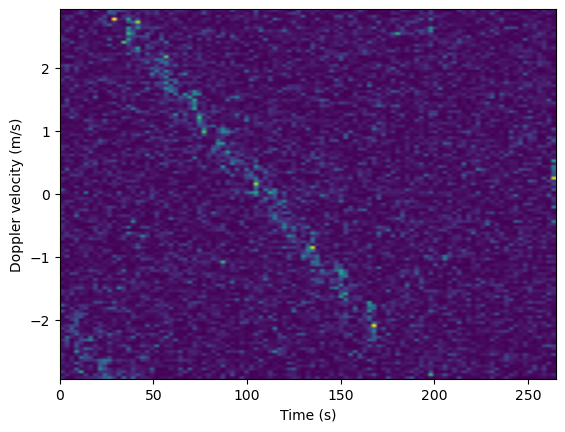

In [107]:
plt.imshow(spectrogram[:, :], origin='lower', extent=[time_axis[0], time_axis[-1], vel[0], vel[-1]], aspect='auto')
plt.xlabel('Time (s)')
plt.ylabel('Doppler velocity (m/s)')
plt.show()

In [112]:
low = np.argmax(incoho_sum)-1000
high = np.argmax(incoho_sum)+1000

In [30]:
range_axis[3]-range_axis[2]

np.float64(9.36854403503818)

In [113]:
low

np.int64(191082)

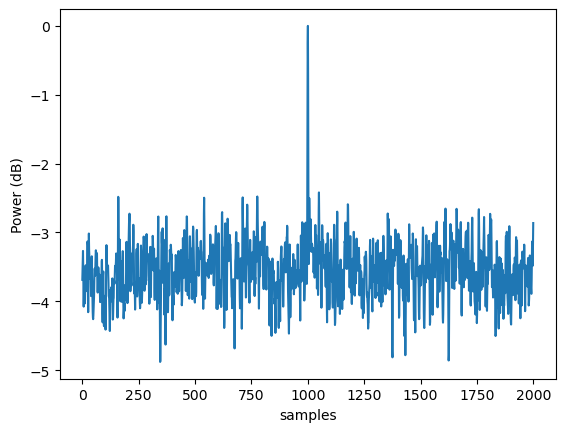

In [50]:
plt.plot(10*np.log10(incoho_sum +1e-12)-np.max(10*np.log10(incoho_sum +1e-12)))
plt.xlabel('samples')
plt.ylabel('Power (dB)')
plt.show()

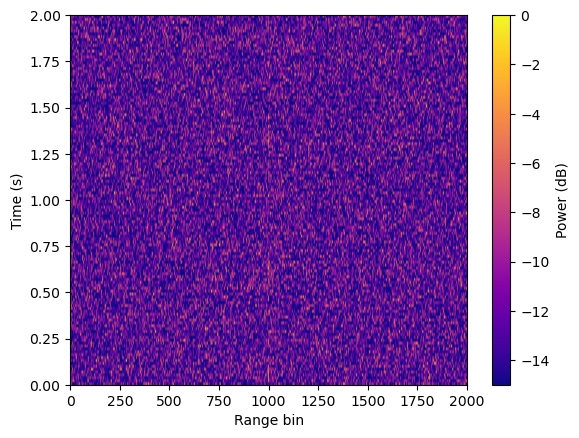

In [53]:
intensity_db = 10 * np.log10(np.abs(windowed_cdat_pc)**2 + 1e-12)
intensity_db -= np.max(intensity_db)
plt.imshow(intensity_db, aspect='auto', cmap='plasma', vmin=-15, origin='lower', extent=[0, (high-low), 0, int(128*pri)])
plt.xlabel('Range bin')
plt.ylabel('Time (s)')
plt.colorbar(label='Power (dB)')

plt.show()

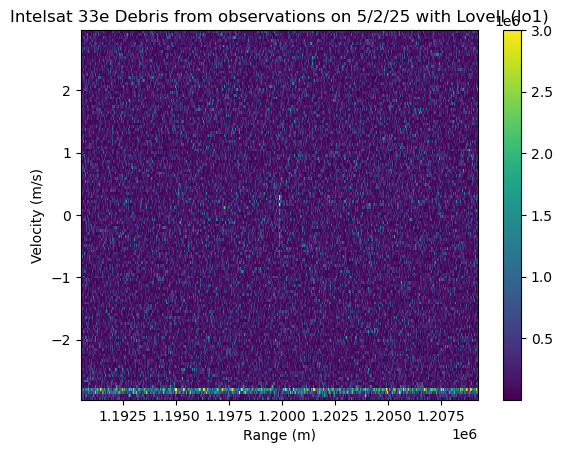

In [23]:
plt.figure()
plt.pcolormesh(range_axis, velocity_axis, np.abs(range_doppler ** 2), shading="auto", vmax=3e6)
plt.colorbar()
plt.xlabel("Range (m)")
plt.ylabel("Velocity (m/s)")
plt.title('Intelsat 33e Debris from observations on 5/2/25 with Lovell (lo1)')
plt.xlim([range_axis[low], range_axis[high]])
plt.show()

In [58]:
range_doppler[:, 0].shape

(128,)

In [24]:
tot_1 = 49500.80709520000 # one time of transmit in seconds since midnight utc
tx_tot = np.unique(np.sort(np.concatenate(
        (np.r_[tot_1:0:-pri], np.r_[tot_1:86400:pri])
    ))) # 86400 seconds in a day, so this creates a full list of transmit times for the entire day, both before and after the transmit time

# time of observation
year = 2025
month = 2
day = 5
hour = 13
minute = 45
obs_date = datetime(year, month, day, hour, minute)

file_size = os.path.getsize(infilename)
num_samples = np.floor(file_size / 2 )
num_ms_sec_vdif = np.floor(num_samples/(samp_rate/2)*1000)

end_time = obs_date + timedelta(seconds=num_ms_sec_vdif/1000)

# now narrowing it down to time of observation
secofday = (obs_date - obs_date.replace(hour=0, minute=0, second=0,
                                        microsecond=0)).total_seconds()
secofday_end = (end_time - end_time.replace(hour=0, minute=0, second=0,
                                                microsecond=0)).total_seconds()

tx_tot = tx_tot[np.where(tx_tot>secofday - 1)]
tx_tot = tx_tot[np.where(tx_tot<secofday_end+ 1)]



bias = 0.0


# telescope
telescope = 'Lovell'
pipeline_geometry = calculate_bistatic_geometry(
        tx_tot=tx_tot,  
        pytime=obs_date,
        sat_tle=tle_list,
        rx=telescope,
        pulsewidth=Tp,
        toa_bias=bias,
        vdif_sample_rate=samp_rate
    )

In [25]:
pipeline_geometry

{'bistatic_range_km': array([85494.444, 85494.444, 85494.444, ..., 85493.124, 85493.124,
        85493.124], shape=(6914,)),
 'rx_toa_sec': array([49499.29997397, 49499.31967397, 49499.33937397, ...,
        49635.44666955, 49635.46636955, 49635.48606955], shape=(6914,)),
 'vdif_target_sample_idx': array([791988799584, 791989114784, 791989429984, ..., 794167146713,
        794167461913, 794167777113], shape=(6914,))}

In [70]:
cdat_pc.shape[0]

128

In [69]:
pipeline_geometry

{'bistatic_range_km': array([86319.44 , 86319.44 , 86319.44 , ..., 86255.404, 86255.404,
        86255.404], shape=(4385787,)),
 'rx_toa_sec': array([2.91676322e-01, 3.11376322e-01, 3.31076322e-01, ...,
        8.64002363e+04, 8.64002560e+04, 8.64002757e+04], shape=(4385787,)),
 'vdif_target_sample_idx': array([      4666821,       4982021,       5297221, ..., 1382403780000,
        1382404095200, 1382404410400], shape=(4385787,))}

In [100]:
window_size = high-low
centre_col=window_size//2
result = calculate_observed_bistatic_range(
        pc_output_window=cdat_pc.flatten(),
        pipeline_geometry=pipeline_geometry,
        vdif_sample_rate=samp_rate,
        search_window_size=window_size
    )

In [101]:
result

{'observed_range_km': array([239274.35313419, 239274.35313419, 239274.35313419, ...,
        239273.03313419, 239273.03313419, 239273.03313419], shape=(6914,)),
 'range_residual_km': np.float64(153779.90913418963),
 'time_residual_sec': np.float64(0.5129545625),
 'peak_snr': np.float64(4.1181956341812755)}

In [102]:
baseline_theoretical_range_km = pipeline_geometry['bistatic_range_km'][0]
sample_offsets = np.arange(window_size) - centre_col
km_per_sample = (c / samp_rate) / 1e3
relative_range_axis_km = sample_offsets * km_per_sample
absolute_range_axis_km = baseline_theoretical_range_km + relative_range_axis_km
slow_time = pipeline_geometry['rx_toa_sec']
intensity_db = 10 * np.log10(np.abs(cdat_pc)**2 + 1e-12)
intensity_db -= np.max(intensity_db)


In [84]:
result['observed_range_km'].shape

(4385787,)

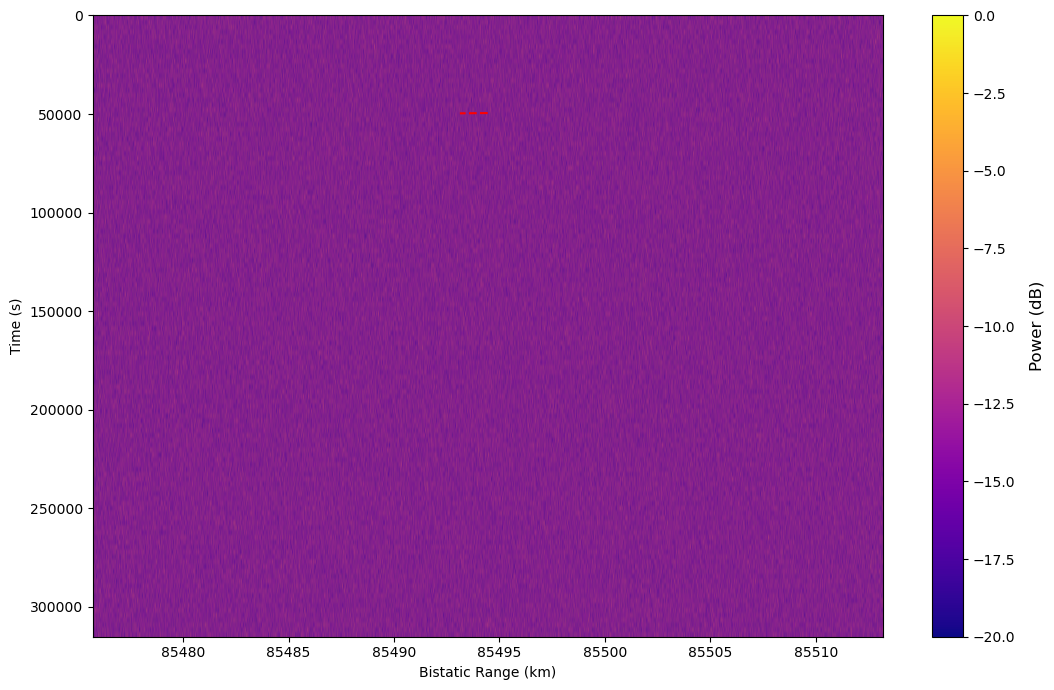

In [103]:
fig, ax = plt.subplots(figsize=(11, 7))
extent = [absolute_range_axis_km[0], absolute_range_axis_km[-1], points, 0]
img = ax.imshow(intensity_db, extent=extent, aspect='auto', cmap='plasma', vmin=-20, vmax=0)
observed_ranges_km = pipeline_geometry['bistatic_range_km']
ax.plot(observed_ranges_km, slow_time, color='red', linestyle='--', linewidth=1.5, label='Observed Echo Peaks')
cbar = fig.colorbar(img, ax=ax)
cbar.set_label("Power (dB)", fontsize=12, labelpad=10)
plt.xlabel('Bistatic Range (km)')
plt.ylabel('Time (s)')
plt.tight_layout()
plt.show()



In [56]:
from PIL import Image
import time
import glob

images = []
timestr = time.strftime("%Y%m%d-%H%M%S")

for filename in sorted(glob.glob('/share/nas2/pryder/tumbling_git/plots/range_doppler*.png')): # loop through all png files in the folder
    im = Image.open(filename)
    print(filename)
    images.append(im)
# calculate the frame number of the last frame (ie the number of images)
last_frame = (len(images))

images[0].save('/share/nas2/pryder/tumbling_git/plots/range_doppler.gif',
               save_all=True, append_images=images[1:], optimize=False, duration=500, loop=0)

/share/nas2/pryder/tumbling_git/plots/range_doppler_01.png
/share/nas2/pryder/tumbling_git/plots/range_doppler_02.png
/share/nas2/pryder/tumbling_git/plots/range_doppler_03.png
/share/nas2/pryder/tumbling_git/plots/range_doppler_04.png
/share/nas2/pryder/tumbling_git/plots/range_doppler_05.png
/share/nas2/pryder/tumbling_git/plots/range_doppler_06.png
/share/nas2/pryder/tumbling_git/plots/range_doppler_07.png
/share/nas2/pryder/tumbling_git/plots/range_doppler_08.png
/share/nas2/pryder/tumbling_git/plots/range_doppler_09.png
/share/nas2/pryder/tumbling_git/plots/range_doppler_10.png
/share/nas2/pryder/tumbling_git/plots/range_doppler_11.png
/share/nas2/pryder/tumbling_git/plots/range_doppler_12.png
/share/nas2/pryder/tumbling_git/plots/range_doppler_13.png
/share/nas2/pryder/tumbling_git/plots/range_doppler_14.png
/share/nas2/pryder/tumbling_git/plots/range_doppler_15.png
/share/nas2/pryder/tumbling_git/plots/range_doppler_16.png
/share/nas2/pryder/tumbling_git/plots/range_doppler_17.p